In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("student_performance - student_performance.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()

Environment ready!
NumPy: 1.24.3
pandas: 1.5.3
scikit-learn: 1.2.2


,study_hours,attendance,assignments
result,,,
0,1.633333,65.037037,5.296296
1,3.824242,76.060606,8.393939


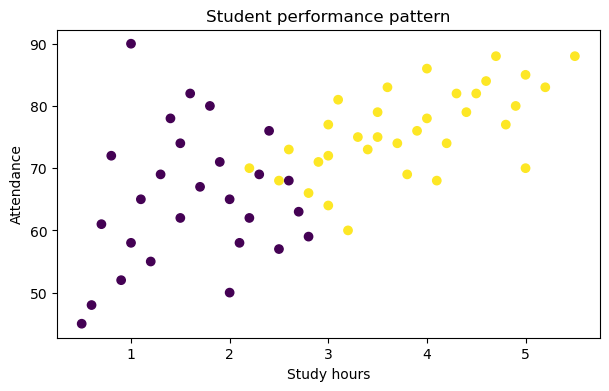

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!


In [17]:
plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

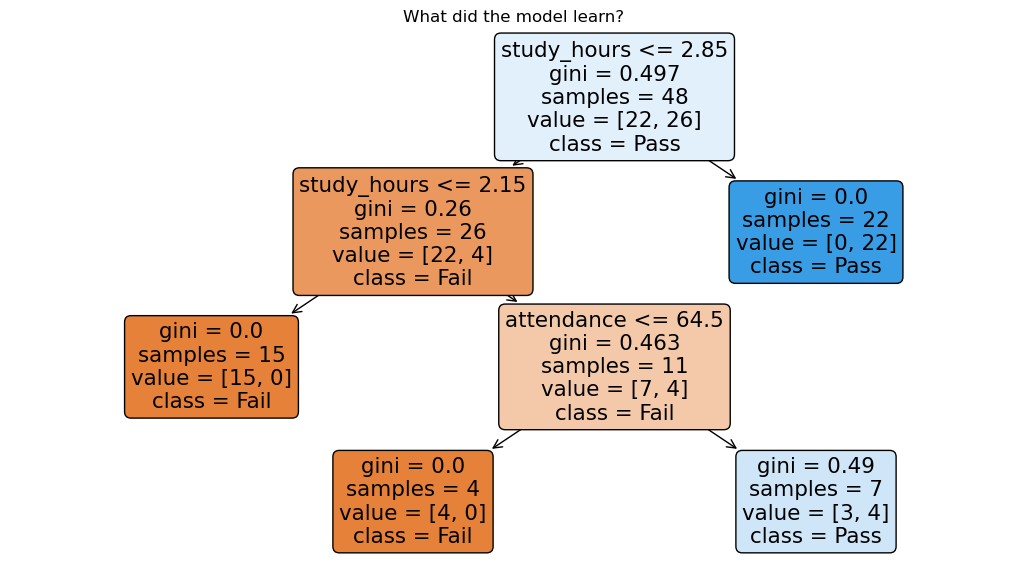

In [18]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()

In [19]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


# ============================================================
# STEP 1: Prepare Sample Data
# ============================================================

emails = [
    "Meeting schedule for tomorrow project review",
    "WIN FREE CASH NOW! CLICK HERE!",
    "Please send the engineering lab report by Friday",
    "Claim your free prize money today",
    "Urgent account verification required",
    "CONGRATULATIONS! You won a brand new car"
]

# 0 = Normal/Safe
# 1 = Spam
labels = [0, 1, 0, 1, 0, 1]


# ============================================================
# STEP 2: Convert Text into Numbers
# ============================================================

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(emails)

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nShape of feature matrix:")
print(X.shape)


# ============================================================
# STEP 3: Train Naive Bayes Model
# ============================================================

model = MultinomialNB()

model.fit(X, labels)

print("\n--- Model Training Complete! ---")


# ============================================================
# STEP 4: Test with New Emails
# ============================================================

new_emails = [
    "Submit your lab assignment tomorrow",
    "Win a free prize and cash bonus now"
]

# Convert new emails using the same vectorizer
X_new = vectorizer.transform(new_emails)

# Predict
predictions = model.predict(X_new)


# ============================================================
# STEP 5: Display Results
# ============================================================

print("\n--- Prediction Results ---\n")

for email, pred in zip(new_emails, predictions):

    if pred == 1:
        status = "SPAM"
    else:
        status = "SAFE / NORMAL"

    print("Email  :", email)
    print("Result :", status)
    print()

Vocabulary:
['account' 'brand' 'by' 'car' 'cash' 'claim' 'click' 'congratulations'
 'engineering' 'for' 'free' 'friday' 'here' 'lab' 'meeting' 'money' 'new'
 'now' 'please' 'prize' 'project' 'report' 'required' 'review' 'schedule'
 'send' 'the' 'today' 'tomorrow' 'urgent' 'verification' 'win' 'won' 'you'
 'your']

Shape of feature matrix:
(6, 35)

--- Model Training Complete! ---

--- Prediction Results ---

Email  : Submit your lab assignment tomorrow
Result : SAFE / NORMAL

Email  : Win a free prize and cash bonus now
Result : SPAM



Dataset:
   student_id  study_hours  attendance  assignments  result
0           1          1.0          58            3       0
1           2          1.5          62            5       0
2           3          2.0          65            6       0
3           4          2.5          68            7       1
4           5          3.0          72            7       1

X shape: (60, 3)
y shape: (60,)

Training rows: 48
Testing rows: 12

-----------------------------
Max Depth: 3
Accuracy: 1.0
Accuracy (%): 100.0

Confusion Matrix:
[[5 0]
 [0 7]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         7

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


-----------------------------
Max Depth: 4
Accuracy: 1.0
Accuracy (%): 100.0

Confusion Matrix:
[[

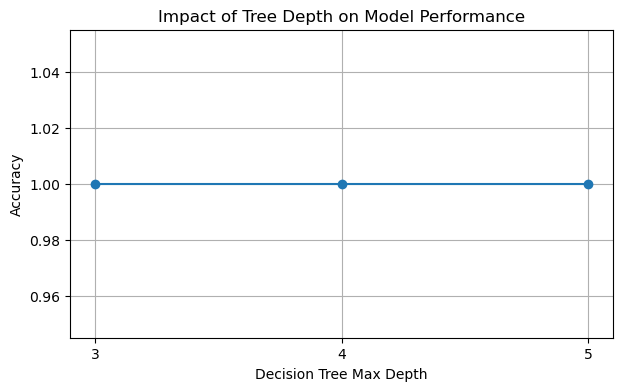

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# --------------------------------------------------
# STEP 1: Load dataset
# --------------------------------------------------

df = pd.read_csv("student_performance - student_performance.csv")

print("Dataset:")
print(df.head())


# --------------------------------------------------
# STEP 2: Define features and target
# --------------------------------------------------

X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------------
# STEP 3: Split dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


# --------------------------------------------------
# STEP 4: Train Decision Trees with different depths
# --------------------------------------------------

depths = [3, 4, 5]
results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Max Depth": depth,
        "Accuracy": accuracy
    })

    print("\n-----------------------------")
    print("Max Depth:", depth)
    print("Accuracy:", accuracy)
    print("Accuracy (%):", accuracy * 100)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# --------------------------------------------------
# STEP 5: Comparative analysis
# --------------------------------------------------

results_df = pd.DataFrame(results)

print("\n===== COMPARISON =====")
print(results_df)


# --------------------------------------------------
# STEP 6: Plot comparison
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    results_df["Max Depth"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Impact of Tree Depth on Model Performance")

plt.xticks([3, 4, 5])
plt.grid(True)

plt.show()

Slope: 1.052121212121212
Intercept: 25.48484848484849

Regression Equation:
Power = 25.48 + 1.05 × Temperature

Mean Squared Error: 0.6496969696969697
R² Score: 0.9971623996781229

Predicted power consumption at 70°C: 99.13333333333333 Watts


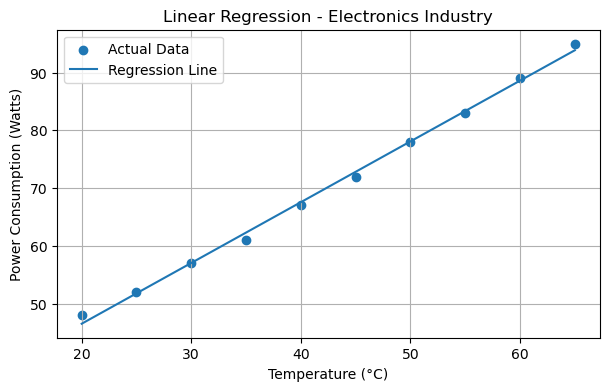

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# --------------------------------------------------
# STEP 1: Sample electronics industry data
# --------------------------------------------------

temperature = np.array([
    20, 25, 30, 35, 40,
    45, 50, 55, 60, 65
])

power = np.array([
    48, 52, 57, 61, 67,
    72, 78, 83, 89, 95
])


# Convert X into 2D format
X = temperature.reshape(-1, 1)
y = power


# --------------------------------------------------
# STEP 2: Create Linear Regression model
# --------------------------------------------------

model = LinearRegression()

model.fit(X, y)


# --------------------------------------------------
# STEP 3: Make predictions
# --------------------------------------------------

y_pred = model.predict(X)


# --------------------------------------------------
# STEP 4: Display equation
# --------------------------------------------------

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print(
    "\nRegression Equation:"
)

print(
    f"Power = {model.intercept_:.2f} + "
    f"{model.coef_[0]:.2f} × Temperature"
)


# --------------------------------------------------
# STEP 5: Evaluate model
# --------------------------------------------------

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nMean Squared Error:", mse)
print("R² Score:", r2)


# --------------------------------------------------
# STEP 6: Predict power at 70°C
# --------------------------------------------------

new_temperature = np.array([[70]])

predicted_power = model.predict(new_temperature)

print(
    "\nPredicted power consumption at 70°C:",
    predicted_power[0],
    "Watts"
)


# --------------------------------------------------
# STEP 7: Plot regression line
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.scatter(
    temperature,
    power,
    label="Actual Data"
)

plt.plot(
    temperature,
    y_pred,
    label="Regression Line"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Power Consumption (Watts)")
plt.title("Linear Regression - Electronics Industry")

plt.legend()
plt.grid(True)

plt.show()

Customer Dataset:
    Annual_Income  Spending_Score
0              15              80
1              16              85
2              17              78
3              18              82
4              20              88
5              40              40
6              42              45
7              45              42
8              47              38
9              50              44
10             70              75
11             72              80
12             75              72
13             78              78
14             80              85

Clustered Dataset:
    Annual_Income  Spending_Score  Cluster
0              15              80        2
1              16              85        2
2              17              78        2
3              18              82        2
4              20              88        2
5              40              40        0
6              42              45        0
7              45              42        0
8              47              

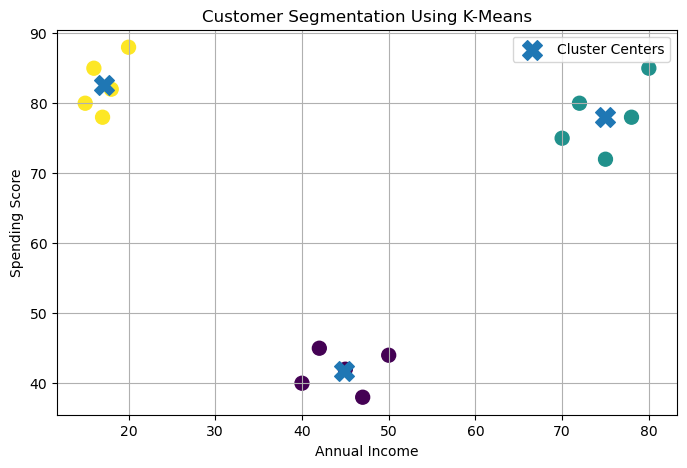

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans


# --------------------------------------------------
# STEP 1: Create sample customer data
# --------------------------------------------------

data = {
    "Annual_Income": [
        15, 16, 17, 18, 20,
        40, 42, 45, 47, 50,
        70, 72, 75, 78, 80
    ],

    "Spending_Score": [
        80, 85, 78, 82, 88,
        40, 45, 42, 38, 44,
        75, 80, 72, 78, 85
    ]
}

df = pd.DataFrame(data)

print("Customer Dataset:")
print(df)


# --------------------------------------------------
# STEP 2: Select features
# --------------------------------------------------

X = df[
    ["Annual_Income", "Spending_Score"]
]


# --------------------------------------------------
# STEP 3: Apply K-Means
# --------------------------------------------------

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = model.fit_predict(X)


# --------------------------------------------------
# STEP 4: Display results
# --------------------------------------------------

print("\nClustered Dataset:")
print(df)


# --------------------------------------------------
# STEP 5: Display cluster centers
# --------------------------------------------------

print("\nCluster Centers:")
print(model.cluster_centers_)


# --------------------------------------------------
# STEP 6: Visualize clusters
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation Using K-Means")

plt.legend()
plt.grid(True)

plt.show()